In [1]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

# ==================================================
# Nom du Projet : Driver Drowsiness Detection Project
# Fichier : main.ipynb
# Auteur : Rajaa LEBNAITI
# Email : rajaa.lebnaiti@gmail.com

# ==================================================

# Copyright 2025
# ==================================================

<h1><center> Driver Drowsiness Detection Project </center></h1>

<h4>☕ Realisé par:</h4>
<ul>
    <li>Rajaa Lebnaiti</li>
</ul>


<h5> ✉ Email:   <a href="mailto:rajaa.lebnaiti@gmail.com">  rajaa.lebnaiti@gmail.com</a></h5>
<h5>🌐 LinkedIn:   <a href="https://www.linkedin.com/in/lebnaiti-rajaa/" target="_blank">  https://www.linkedin.com/in/lebnaiti-rajaa/</a></h5>
<h5>💼 GitHub:   <a href="https://github.com/RajaaLebnaiti" target="_blank">  https://github.com/RajaaLebnaiti/</a></h5>




In [2]:
# Importing librairies
import pandas as pd  

import numpy as np  

import matplotlib.pyplot as plt 

import seaborn as sns

import os

import glob

from PIL import Image  

from tensorflow.keras.preprocessing.image import ImageDataGenerator

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

from tensorflow.keras.models import load_model

from sklearn.metrics import confusion_matrix

import seaborn as sns

from sklearn.model_selection import train_test_split

<h1> 1)- Data Preparation

<h2> 1-1)- Uploading the dataset

In [3]:
# Importing the data

# Step 1: Define the dataset path
#dataset_path = '/kaggle/input/datasetdriverdrowsinessdetection/Data/dataset_new/train'  
dataset_path = 'C:\\Users\\hp\\Desktop\\Driver Drowsiness Detection System\\Data\\dataset_new\\train' 

In [4]:
# Step 2: Load image file paths using glob for each class
closed_images = glob.glob(os.path.join(dataset_path, 'Closed/*.jpg'))
no_yawn_images = glob.glob(os.path.join(dataset_path, 'no_yawn/*.jpg'))
open_images = glob.glob(os.path.join(dataset_path, 'Open/*.jpg'))
yawn_images = glob.glob(os.path.join(dataset_path, 'yawn/*.jpg'))


In [5]:
# Step 3: Check the number of images loaded for each class
print(f"Closed: {len(closed_images)} images")
print(f"No-yawn: {len(no_yawn_images)} images")
print(f"Open: {len(open_images)} images")
print(f"Yawn: {len(yawn_images)} images")

Closed: 617 images
No-yawn: 616 images
Open: 617 images
Yawn: 617 images


The dataset is well-balanced, which is a good sign. We have approximately the same number of images in each class (around 616–617 images), so the model shouldn’t suffer from class imbalance.

In [6]:
# Step 4: Visualize some images 


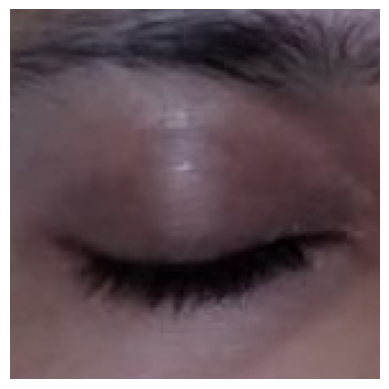

In [7]:
# Load and display an image from 'Closed' class
example_image = Image.open(closed_images[0])  # Load one image from 'Closed'

# Display the image using matplotlib
plt.imshow(example_image)
plt.axis('off')  
plt.show()

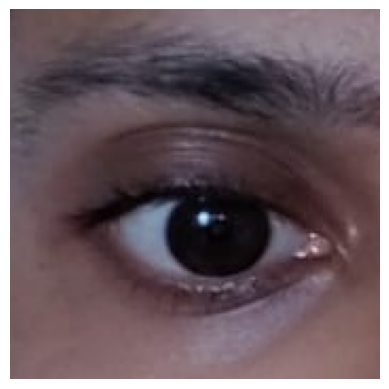

In [8]:
# Load and display an image from 'Open' class
example_image = Image.open(open_images[0])  # Load one image from 'Open'

# Display the image using matplotlib
plt.imshow(example_image)
plt.axis('off')  
plt.show()

the width of the image is :  640
the height of the image is :  480


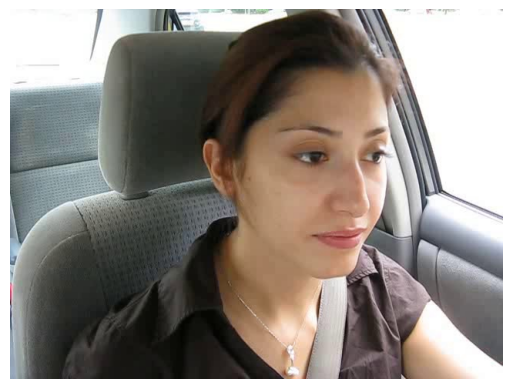

In [9]:
# Load and display an image from 'no-yawn' class
example_image = Image.open(no_yawn_images[0])
print("the width of the image is : " ,example_image.width)
print("the height of the image is : " ,example_image.height)

# Display the image using matplotlib
plt.imshow(example_image)
plt.axis('off')  
plt.show()

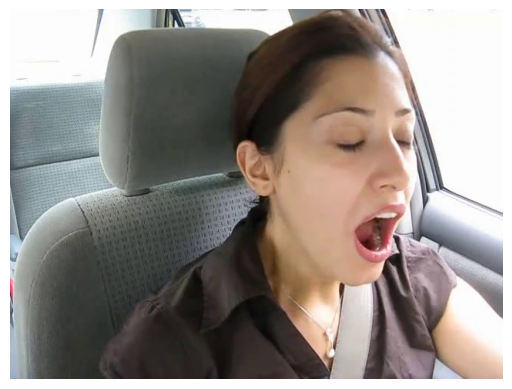

In [10]:
# Load and display an image from 'yawn' class
example_image = Image.open(yawn_images[0])  # Load one image from 'yawn'
# Display the image using matplotlib
plt.imshow(example_image)
plt.axis('off') 
plt.show()

# Initial images in gray scale

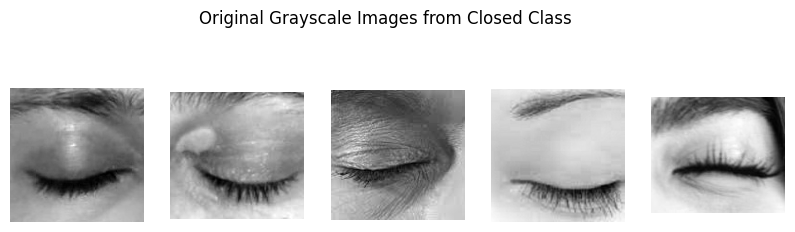

In [11]:
import matplotlib.pyplot as plt
from PIL import Image

# Load and display 5 images from the 'Closed' class in grayscale
num_images = 5
plt.figure(figsize=(10, 3)) 

for i in range(num_images):
    # Load the image
    image = Image.open(closed_images[i]) 
    
    # Convert the image to grayscale
    image = image.convert('L') 
    
    # Plot the image
    plt.subplot(1, num_images, i + 1) 
    plt.imshow(image, cmap='gray')  
    plt.axis('off')  

plt.suptitle('Original Grayscale Images from Closed Class')  
plt.show()


<h1> 2)- Data Splitting into training and validation

<h3> split the data set 

In [12]:
# Step 1: Split your dataset paths
all_images = closed_images +  open_images +no_yawn_images + yawn_images
labels = ['Closed'] * len(closed_images) + ['Open'] * len(open_images) + ['No-yawn'] * len(no_yawn_images) + ['Yawn'] * len(yawn_images)

# Split into training and validation (80% training, 20% validation)
train_images, val_images, train_labels, val_labels = train_test_split(all_images, labels, test_size=0.2, random_state=42)


In [13]:
len(train_images)

1973

In [14]:
len(val_images)

494

<h3> applying data augmentation on the training data 

In [15]:
# Step 2: Define the ImageDataGenerator for the training set (with augmentation)
train_datagen = ImageDataGenerator(
    
    
    rescale=1./255,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    fill_mode='nearest'
    
    
)



<ul>
<li>
Rescaling: Normalize pixel values.
</li>
<li>
Rotation: Randomly rotate images.
</li>
<li>
Width/Height shift: Shift images horizontally and vertically.
</li>
<li>
Shear: Apply a shearing transformation.
</li>
<li>
Zoom: Randomly zoom in or out.
</li>
<li>
Horizontal flip: Randomly flip images horizontally.
</li>
<li>
Fill mode: Handle any pixels created by shifts or rotations.
</li>

<h3> Rescaling the validation data (no augmentation)

In [16]:
# Only rescale for validation set (no augmentation)
val_datagen = ImageDataGenerator(
    rescale=1./255  # Normalize validation images
)

In [17]:
# Step 3: Create generators

train_generator = train_datagen.flow_from_dataframe(
    dataframe=pd.DataFrame({'filename': train_images, 'class': train_labels}),
    x_col='filename',
    y_col='class',
    target_size=(224, 224), 
    batch_size=32,
    class_mode='categorical'
)

Found 1973 validated image filenames belonging to 4 classes.


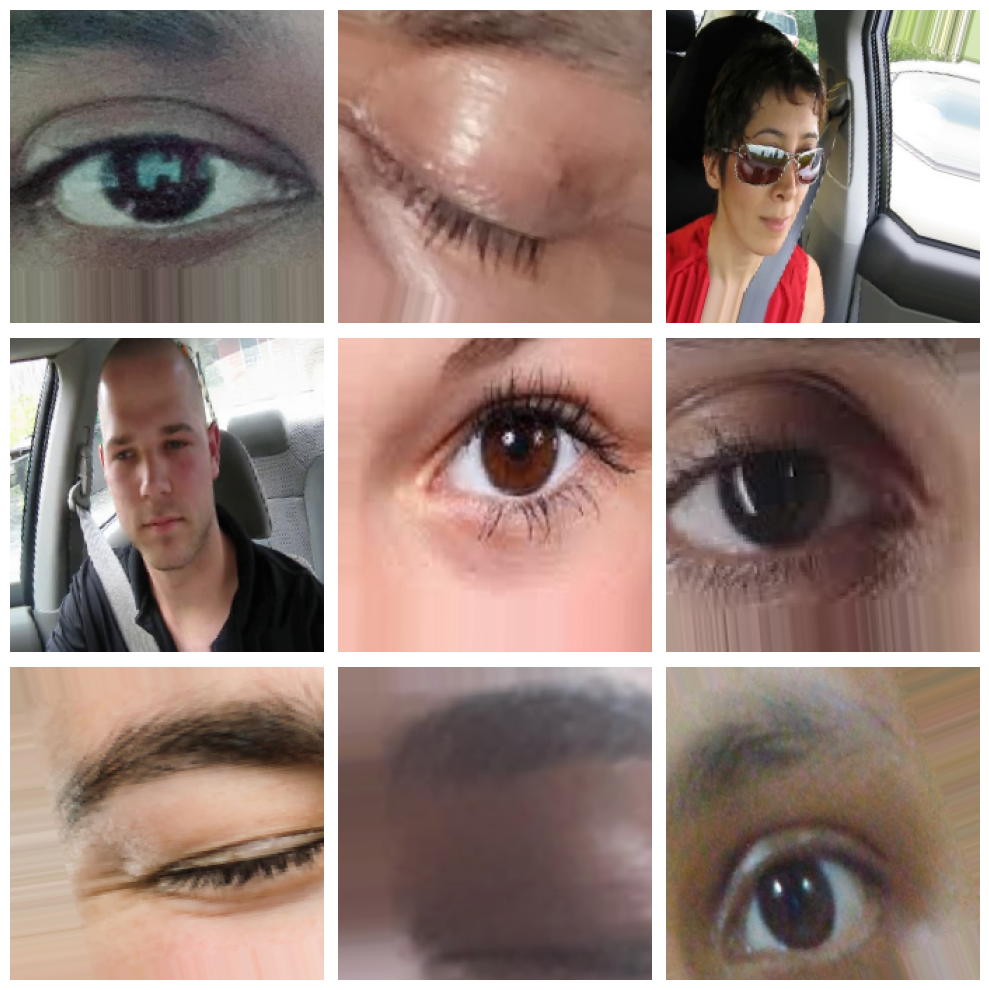

In [18]:
# Visualize some of the training images after data augmentation

# Get a batch of augmented images and labels from the generator
images, labels = next(train_generator)  # This returns a batch of images
plt.figure(figsize=(10, 10))

for i in range(9):  
    plt.subplot(3, 3, i + 1)
    plt.imshow(images[i])  
    plt.axis('off')  

plt.tight_layout()
plt.show()

In [19]:
val_generator = val_datagen.flow_from_dataframe(
    dataframe=pd.DataFrame({'filename': val_images, 'class': val_labels}),
    x_col='filename',
    y_col='class',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

Found 494 validated image filenames belonging to 4 classes.


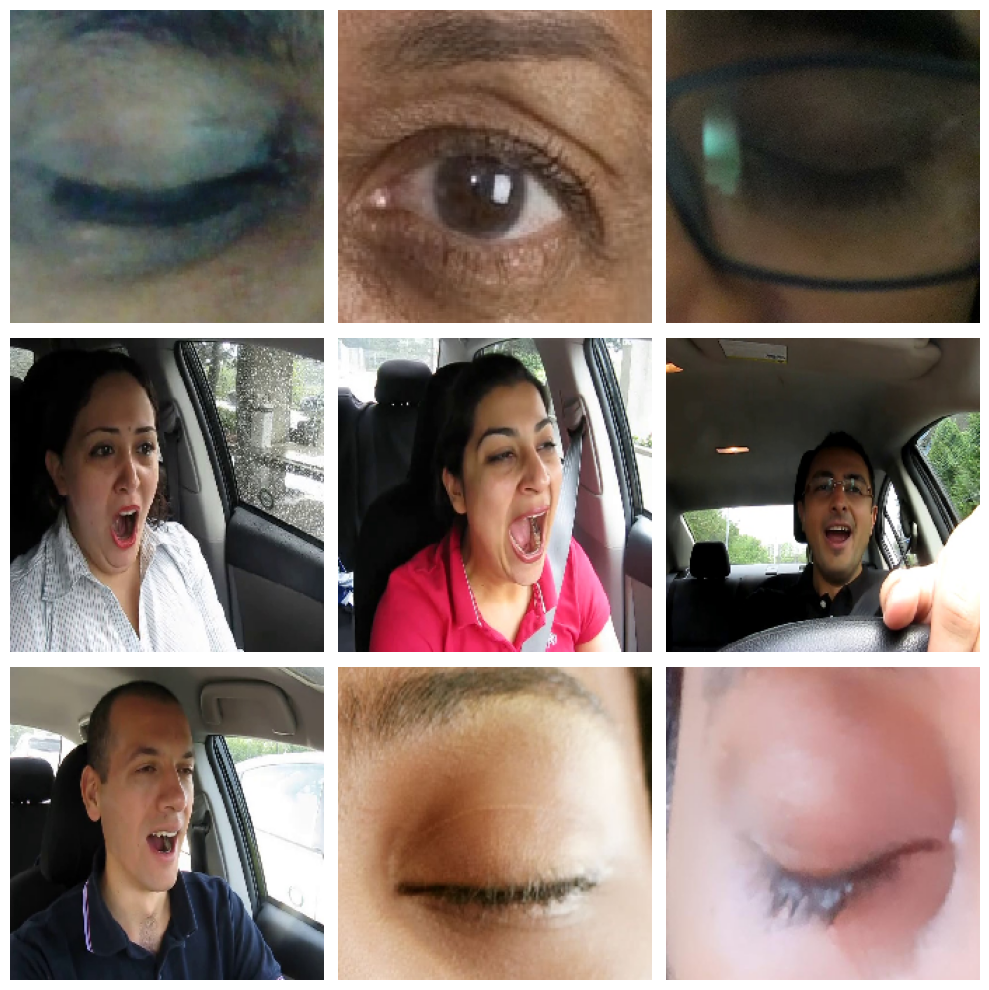

In [20]:
# Visualize some of the validation images
# Get a batch of validation images and labels from the generator
val_images_batch, val_labels_batch = next(val_generator) 

# Set up a grid to display multiple images
plt.figure(figsize=(10, 10))

for i in range(9):  # Display 9 images in a 3x3 grid
    plt.subplot(3, 3, i + 1)
    plt.imshow(val_images_batch[i]) 
    plt.axis('off')  

plt.tight_layout()
plt.show()

<h3> Load the test data

In [21]:
# Load the test data for evaluation 
# Step 1: Create a data generator for test data (without augmentation, only normalization)

class_names = ['Closed', 'no_yawn', 'Open', 'yawn']

test_images = []
test_labels = []

for class_name in class_names: 
    class_path = os.path.join('C:\\Users\\hp\\Desktop\\Driver Drowsiness Detection System\\Data\\dataset_new\\test', class_name)
    for img_path in glob.glob(os.path.join(class_path, '*.jpg')):
        test_images.append(img_path)
        test_labels.append(class_name)

test_df = pd.DataFrame({'filename': test_images, 'class': test_labels})

test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col='filename',
    y_col='class',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False,
    classes=class_names  
)


Found 433 validated image filenames belonging to 4 classes.
Test class indices: {'Closed': 0, 'no_yawn': 1, 'Open': 2, 'yawn': 3}


"test_data_generator = ImageDataGenerator(rescale=1./255)\n\n# Step 2: Load test data from the 'test' folder\ntest_generator = test_data_generator.flow_from_directory(\n    directory='/kaggle/input/datasetdriverdrowsinessdetection/Data/dataset_new/test',   # Replace with the path to your test dataset\n    target_size=(224, 224),            # Resize images to match input size of your model (224x224 in this case)\n    batch_size=32,                     # Batch size for testing\n    class_mode='categorical',          # Categorical labels\n    shuffle=False                     # Don't shuffle test data so you can evaluate it properly\n     \n)\n"

In [22]:
print(test_df.head())  
print(test_df['class'].value_counts())  

                                            filename   class
0  C:\Users\hp\Desktop\Driver Drowsiness Detectio...  Closed
1  C:\Users\hp\Desktop\Driver Drowsiness Detectio...  Closed
2  C:\Users\hp\Desktop\Driver Drowsiness Detectio...  Closed
3  C:\Users\hp\Desktop\Driver Drowsiness Detectio...  Closed
4  C:\Users\hp\Desktop\Driver Drowsiness Detectio...  Closed
Closed     109
no_yawn    109
Open       109
yawn       106
Name: class, dtype: int64


In [23]:
print("Class Indices:", train_generator.class_indices)


Class Indices: {'Closed': 0, 'No-yawn': 1, 'Open': 2, 'Yawn': 3}


In [24]:

class_indices = test_generator.class_indices
print(class_indices)


{'Closed': 0, 'no_yawn': 1, 'Open': 2, 'yawn': 3}


In [25]:
unique_classes, counts = np.unique(test_generator.classes, return_counts=True)
print("Classes réelles dans le jeu de test :", dict(zip(unique_classes, counts)))

Classes réelles dans le jeu de test : {0: 109, 1: 109, 2: 109, 3: 106}


<h1> 3)- Model Building

Define CNN Architecture

Compile the Model: Choose an optimizer (like Adam), a loss function (e.g., categorical cross-entropy), and metrics (like accuracy).


Data Generator: Use ImageDataGenerator for real-time image 
augmentation and batch processing.


In [26]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import seaborn as sns
from tensorflow.keras.regularizers import l2
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Model
from tensorflow.keras.applications import MobileNet
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.utils import class_weight



In [27]:

base_model = MobileNet(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Geler les couches de base
for layer in base_model.layers[-10:]:  # Déverrouiller les 10 dernières couches
    layer.trainable = False

# Ajout des couches personnalisées
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)  # Normalisation des données
x = Dense(128, activation='relu', kernel_regularizer=l2(0.01))(x)  # Couche dense avec régularisation L2
x = Dropout(0.5)(x)  # Dropout pour éviter l'overfitting




output = Dense(4, activation='softmax')(x)  # 4 classes à prédire

# Création du modèle
model = Model(inputs=base_model.input, outputs=output)


In [28]:


# Compilation du modèle avec un taux d'apprentissage réduit
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-5)  # Taux d'apprentissage très bas
model.compile(optimizer=optimizer,
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Callbacks pour éviter l'overfitting
early_stopping = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=10, min_lr=1e-7)

<h1> 4)- Model Training

<h4> Early stopping

In [118]:




history = model.fit(train_generator, validation_data=val_generator, epochs=40, callbacks=[early_stopping, reduce_lr], verbose=1)



Epoch 1/40


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


62/62 ━━━━━━━━━━━━━━━━━━━━ 68s 684ms/step - accuracy: 0.3040 - loss: 4.2789 - val_accuracy: 0.5061 - val_loss: 3.4042 - learning_rate: 1.0000e-05
Epoch 2/40
62/62 ━━━━━━━━━━━━━━━━━━━━ 31s 442ms/step - accuracy: 0.4653 - loss: 3.7022 - val_accuracy: 0.6478 - val_loss: 3.0899 - learning_rate: 1.0000e-05
Epoch 3/40
62/62 ━━━━━━━━━━━━━━━━━━━━ 31s 452ms/step - accuracy: 0.5697 - loss: 3.3756 - val_accuracy: 0.7368 - val_loss: 2.8659 - learning_rate: 1.0000e-05
Epoch 4/40
62/62 ━━━━━━━━━━━━━━━━━━━━ 30s 442ms/step - accuracy: 0.6417 - loss: 3.1369 - val_accuracy: 0.8097 - val_loss: 2.7340 - learning_rate: 1.0000e-05
Epoch 5/40
62/62 ━━━━━━━━━━━━━━━━━━━━ 34s 502ms/step - accuracy: 0.6726 - loss: 3.0621 - val_accuracy: 0.8441 - val_loss: 2.6402 - learning_rate: 1.0000e-05
Epoch 6/40
62/62 ━━━━━━━━━━━━━━━━━━━━ 36s 522ms/step - accuracy: 0.7369 - loss: 2.9083 - val_accuracy: 0.8806 - val_loss: 2.5727 - learning_rate: 1.0000e-05
Epoch 7/40
62/62 ━━━━━━━━━━━━━━━━━━━━ 30s 438ms/step - accuracy: 0.73

<h1> 4)- Model Evaluation

In [119]:
print("Class Indices:", train_generator.class_indices)
print("Class Indices:", test_generator.class_indices)


# Évaluation du modèle sur les données de test
test_loss, test_acc = model.evaluate(test_generator, verbose=1)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

Class Indices: {'Closed': 0, 'No-yawn': 1, 'Open': 2, 'Yawn': 3}
Class Indices: {'Closed': 0, 'no_yawn': 1, 'Open': 2, 'yawn': 3}
14/14 ━━━━━━━━━━━━━━━━━━━━ 4s 307ms/step - accuracy: 0.9912 - loss: 2.0280
Test Loss: 2.0243
Test Accuracy: 0.9931


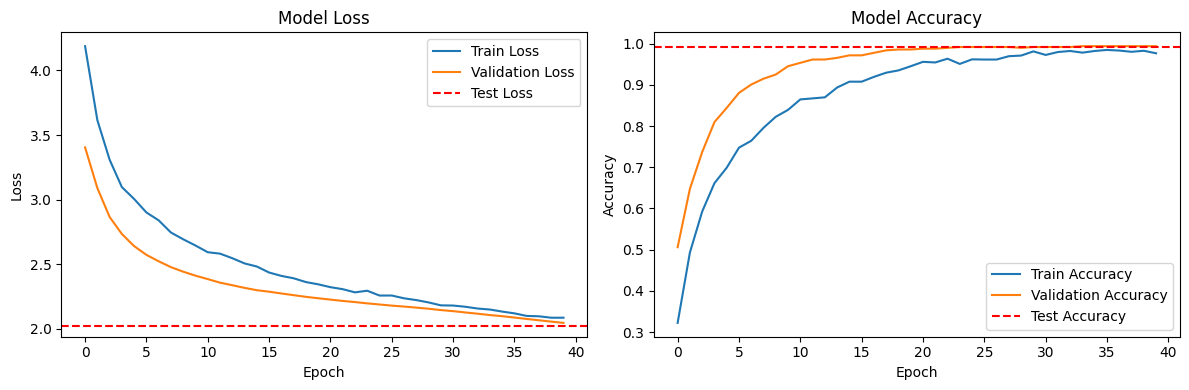

In [120]:
# Plot training & validation & test loss values
plt.figure(figsize=(12, 4))

# Sous-plot pour les pertes (loss)
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.axhline(y=test_loss, color='r', linestyle='--', label='Test Loss') 
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

#  Plot training & validation & test accuracy values
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.axhline(y=test_acc, color='r', linestyle='--', label='Test Accuracy')  
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

Class Indices: {'Closed': 0, 'No-yawn': 1, 'Open': 2, 'Yawn': 3}
Class Indices: {'Closed': 0, 'no_yawn': 1, 'Open': 2, 'yawn': 3}
14/14 ━━━━━━━━━━━━━━━━━━━━ 4s 214ms/step


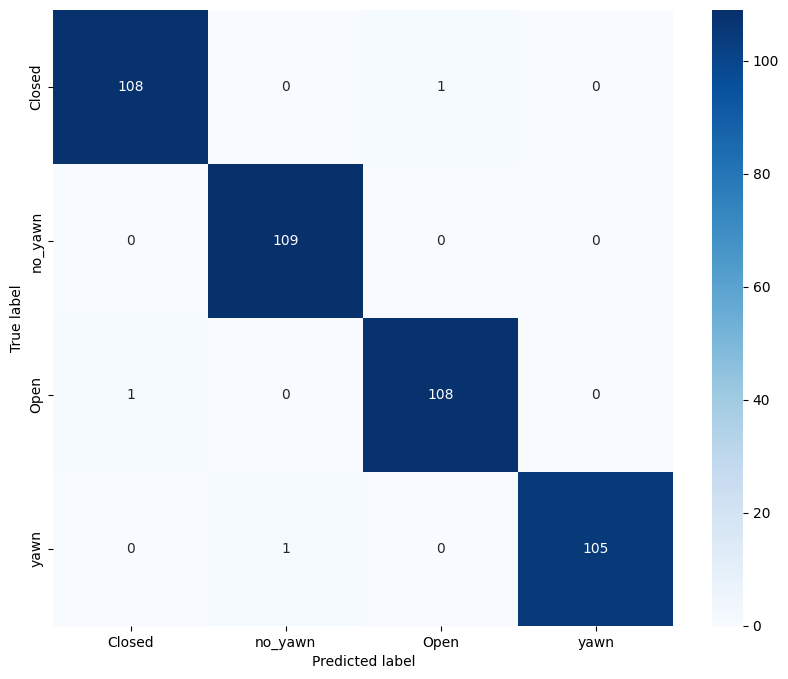

In [121]:
print("Class Indices:", train_generator.class_indices)
print("Class Indices:", test_generator.class_indices)

Y_pred = model.predict(test_generator)
y_pred = np.argmax(Y_pred, axis=1)
cm = confusion_matrix(test_generator.classes, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap='Blues', xticklabels=test_generator.class_indices.keys(), yticklabels=test_generator.class_indices.keys())
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show()


<h1> 5)- Model Saving

In [122]:
# Save the entire model after training
model.save('driver_drowsiness_BEST_model.h5')

<h1> 6)- Model loading

In [3]:


# Load the model
#saved_model = load_model('driver_drowsiness_BEST_model.h5')  



<h1> 7)- Real-time Detection with Webcam

In [4]:
import cv2
import numpy as np
import time
from tensorflow.keras.models import load_model
import pygame

def play_alarm():
    pygame.mixer.init()
    pygame.mixer.music.load('alarm.wav')  
    pygame.mixer.music.play()


# Charger le modèle
try: 
    model = load_model('driver_drowsiness_BEST_model.h5')  # Assurez-vous que le chemin est correct
    print("Modèle chargé avec succès.")
except Exception as e:
    print(f"Erreur lors du chargement du modèle : {e}")
    exit()

# Définir les classes
class_labels = ['Closed', 'Open', 'No-yawn', 'Yawn']

# Charger les classificateurs en cascade
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
eye_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_eye.xml')
mouth_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_smile.xml')

if face_cascade.empty() or eye_cascade.empty() or mouth_cascade.empty():
    print("Erreur : Impossible de charger les classificateurs en cascade.")
    exit()

cap = cv2.VideoCapture(0)
if not cap.isOpened():
    print("Erreur : Impossible d'ouvrir la webcam.")
    exit()

# Initialiser le timer pour la détection de somnolence
closed_start_time = None
alarm_triggered = False

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        print("Erreur : Impossible de lire l'image de la webcam.")
        break

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(gray, 1.3, 5)

    for (x, y, w, h) in faces:
        face_roi = frame[y:y+h, x:x+w]
        cv2.rectangle(frame, (x, y), (x+w, y+h), (255, 0, 0), 2)
        face_gray = gray[y:y+h, x:x+w]
        
        eyes = eye_cascade.detectMultiScale(face_gray, 1.1, 10)
        for (ex, ey, ew, eh) in eyes:
            eye_roi = face_roi[ey:ey+eh, ex:ex+ew]
            eye_img = cv2.resize(eye_roi, (224, 224)).astype('float32') / 255.0
            eye_img = np.expand_dims(eye_img, axis=0)
            
            prediction = model.predict(eye_img)
            predicted_class = np.argmax(prediction, axis=1)[0]
            label = class_labels[predicted_class]
            
            cv2.putText(frame, label, (x, y - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 255, 0), 2)
            cv2.rectangle(face_roi, (ex, ey), (ex+ew, ey+eh), (0, 255, 0), 2)

            # Vérifier la détection de "Closed"
            if label == 'Closed':
                if closed_start_time is None:
                    closed_start_time = time.time()
                elif time.time() - closed_start_time >= 3:  # 3 secondes
                    if not alarm_triggered:
                        print("Alerte ! Somnolence détectée.")
                        play_alarm() # Jouer l'alerte sonore
                        alarm_triggered = True
            else:
                closed_start_time = None
                alarm_triggered = False

    cv2.imshow('Real-Time Detection', frame)
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()


Modèle chargé avec succès.
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 916ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 204ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━